# GOLD RECOVERY

## Objetivo

Predecir la recuperación de oro en la planta de flotación usando los datos de proceso.

## Consideraciones

Los datos se indexan con la fecha y la hora de adquisición (date). Los parámetros cercanos en el tiempo suelen ser similares.

Algunos parámetros no están disponibles porque fueron medidos o calculados mucho más tarde. Por eso, algunas de las características que están presentes en el conjunto de entrenamiento pueden estar ausentes en el conjunto de prueba. El conjunto de prueba tampoco contiene objetivos.

El dataset fuente contiene los conjuntos de entrenamiento y prueba con todas las características.

## Carga de datos y librerias

In [133]:
# Cargaré todas las librerías que necesito.
import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option('display.max_columns', 120)
plt.style.use('ggplot')
RANDOM_STATE = 42

In [ ]:
# Cargaré los datos del nuevo dataset.
BASE_PATH = '/Users/brisna/github_projects/tripleten/gold_recovery/'
PATH_TRAIN = BASE_PATH + 'gold_recovery_train.csv'
PATH_TEST  = BASE_PATH + 'gold_recovery_test.csv'
PATH_FULL  = BASE_PATH + 'gold_recovery_full.csv'

train_raw = pd.read_csv(PATH_TRAIN, parse_dates=['date'], index_col='date')
test_raw  = pd.read_csv(PATH_TEST, parse_dates=['date'], index_col='date')
full_raw  = pd.read_csv(PATH_FULL, parse_dates=['date'], index_col='date')

print('Train shape:', train_raw.shape)
print('Test  shape:', test_raw.shape)
print('Full  shape:', full_raw.shape)


Train shape: (16860, 86)
Test  shape: (5856, 52)
Full  shape: (22716, 86)


## Preparación de datos

In [135]:
# Comprobaré que el cálculo de la recuperación sea correcto.
def calc_recovery(df, metal='au'):
    F = df[f'rougher.input.feed_{metal}']
    C = df[f'rougher.output.concentrate_{metal}']
    T = df[f'rougher.output.tail_{metal}']
    return (C * (F - T) / (F * (C - T))) * 100

mae = np.abs(calc_recovery(train_raw) - train_raw['rougher.output.recovery']).mean()
print(f"MAE recovery ≈ {mae:.6f}")

MAE recovery ≈ 0.000000


In [136]:
# Realizaré una imputación de datos con el uso de la mediana.
TH_NULL = 0.5
cols_keep = train_raw.columns[train_raw.isna().mean() < TH_NULL]
TARGETS = ['rougher.output.recovery', 'final.output.recovery']
feature_cols = list(set(cols_keep) & set(test_raw.columns))
print('Features finales:', len(feature_cols))

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(train_raw[feature_cols]),
                       columns=feature_cols, index=train_raw.index)
X_test  = pd.DataFrame(imputer.transform(test_raw[feature_cols]),
                       columns=feature_cols, index=test_raw.index)

y_train = train_raw[TARGETS]

Features finales: 52


In [137]:
# Eliminaré los outliers.
def total_metals(df):
    total = pd.Series(0.0, index=df.index)
    for m in ['au','ag','pb']:
        total += df[[c for c in df.columns if f'_{m}' in c]].sum(axis=1)
    return total

mask_bad = total_metals(train_raw) <= 0
print('Filas con valores imposibles:', mask_bad.sum())
X_train = X_train.loc[~mask_bad]
y_train = y_train.loc[~mask_bad]

Filas con valores imposibles: 904


In [138]:
#Eliminaré las filas que contengan NaN.
mask_nan = y_train.isna().any(axis=1)
print('Filas con NaN en targets:', mask_nan.sum())
X_train = X_train.loc[~mask_nan]
y_train = y_train.loc[~mask_nan]

Filas con NaN en targets: 1824


HALLAZGOS PRELIMINARES.

- El MAE entre el valor calculado y el proporcionado es de 0.000 lo cuál indica que la métrica de recuperación en el archivo es consistente.

- Después de descartar columnas con más del 50% de nulos, dejé 52 features que están presentes en ambos datasets(train y test).

- Imputé los nulos restantes con el uso de la mediana.
  
- Eliminé 904 filas por valores imposibles lo que representa el 5.4% del total.

- Asímismo, eliminé 1824 filas que contenían NaN lo que representa el 10.8% del total.

- Mi dataset para modelado es de (14132, 52)

## Análisis exploratorio de datos

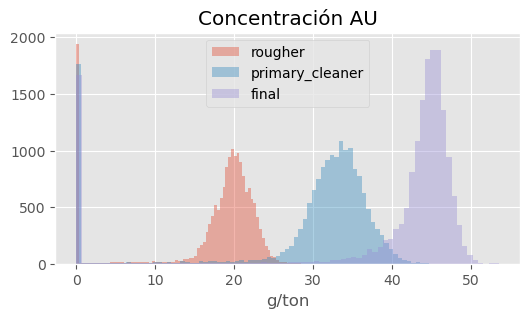

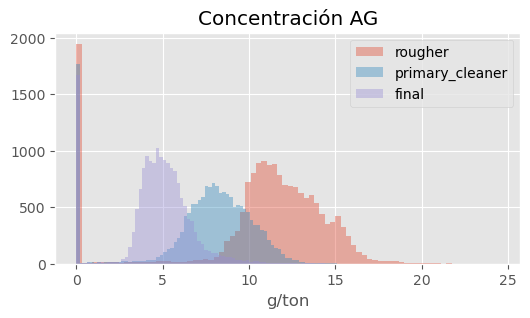

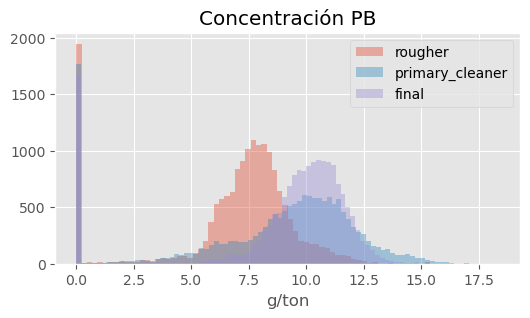

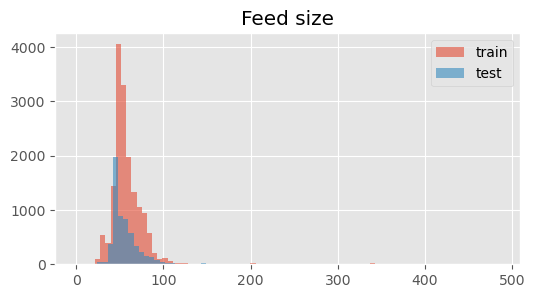

In [139]:
# Revisaré la concentración de cada metal.
for metal in ['au','ag','pb']:
    plt.figure(figsize=(6,3))
    for stage in ['rougher','primary_cleaner','final']:
        col = f'{stage}.output.concentrate_{metal}'
        if col in train_raw:
            train_raw[col].hist(bins=80, alpha=0.4, label=stage)
    plt.title(f'Concentración {metal.upper()}')
    plt.legend(); plt.xlabel('g/ton'); plt.show()

plt.figure(figsize=(6,3))
train_raw['rougher.input.feed_size'].hist(alpha=0.6, bins=80, label='train')
test_raw['rougher.input.feed_size'].hist(alpha=0.6, bins=80, label='test')
plt.title('Feed size'); plt.legend(); plt.show()

Puedo observar que:

- La concentración de oro aumenta en cada etapa de purificación. El rango de cada pico está bien separado, lo que sugiere que cada etapa añade valor de forma consistente.
  
- La plata disminuye en las etapas posteriores: el proceso se centra en oro y relega parte de la plata a las colas. Esto es coherente con un circuito diseñado para maximizar oro.
  
- El plomo aumenta ligeramente de rougher a primary_cleaner y se estabiliza en la etapa final. El enriquecimiento no es tan marcado como en el oro; el circuito probablemente arrastra algo de plomo junto al oro.
 
- Feed size (comparación train vs test). Ambas curvas se solapan casi por completo, centradas en 50‑70 µm; pocos outliers > 150 µm.	No hay drift evidente entre train y test en la variable de tamaño de partícula, lo que respalda que los datos de prueba son representativos del entrenamiento. Los outliers extremos (≥ 300 µm) son escasos.

- El oro se enriquece fuertemente, la plata se pierde (lo que probablemente sea intencional) y el plomo se mantiene con estable‑ligero aumento.

- Las distribuciones confirman que el circuito opera de forma coherente con la metalurgia esperada.

- Al no observar drift en la variable física más sensible (feed size), podemos confiar en que las métricas del modelo serán comparables en train y test.

## Entrenamiento del modelo

In [ ]:
# Entrenaré un árbol de Decisión, Random Forest y Gradient Boosting.
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))/2
    return np.mean(np.where(denom != 0, np.abs(y_true - y_pred) / denom, 0))

scorer = make_scorer(smape, greater_is_better=False)

kf = KFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

models = {
    'DT': DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    'RF': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    'GB': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

for name, model in models.items():
    r = cross_val_score(model, X_train, y_train['rougher.output.recovery'], cv=kf, scoring=scorer).mean()
    f = cross_val_score(model, X_train, y_train['final.output.recovery'],   cv=kf, scoring=scorer).mean()
    print(f"{name}: sMAPE composite {0.25*r + 0.75*f:.4f}")

DT: sMAPE composite -0.0896
RF: sMAPE composite -0.0824
GB: sMAPE composite -0.0829


In [141]:
# Agregaré GridSearch para el modelo GB.
param_gb = {'n_estimators':[200,400], 'learning_rate':[0.05,0.1], 'max_depth':[3,4]}
search = GridSearchCV(GradientBoostingRegressor(random_state=RANDOM_STATE),
                      param_gb, cv=kf, scoring=scorer, n_jobs=-1)
search.fit(X_train, y_train['final.output.recovery'])
print('Mejor GB params ->', search.best_params_)
print('Mejor sMAPE final ->', search.best_score_)

best_params = search.best_params_
model_final   = GradientBoostingRegressor(random_state=RANDOM_STATE, **best_params).fit(X_train, y_train['final.output.recovery'])
model_rougher = GradientBoostingRegressor(random_state=RANDOM_STATE, **best_params).fit(X_train, y_train['rougher.output.recovery'])

Mejor GB params -> {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400}
Mejor sMAPE final -> -0.07142937035847417


In [142]:
# Realizaré una métrica final del GB ajustado.
cv_r_opt = cross_val_score(model_rougher, X_train, y_train['rougher.output.recovery'], cv=kf, scoring=scorer, n_jobs=-1).mean()
cv_f_opt = cross_val_score(model_final,   X_train, y_train['final.output.recovery'],   cv=kf, scoring=scorer, n_jobs=-1).mean()
print(f"Gradient Boosting ajustado → composite sMAPE {0.25*cv_r_opt + 0.75*cv_f_opt:.4f}")

Gradient Boosting ajustado → composite sMAPE -0.0749


Después del entrenamiento, observo lo siguiente:

  * Árbol de Decisión (DT): ‑0.0896
  * Random Forest (RF): ‑0.0824
  * Gradient Boosting (GB) base: ‑0.0829

Con el GB ajustado (400 árboles, depth 4, LR 0.1) el resultado es de  ‑0.0749 confirmando que el 75% del peso (recuperación final) está bien optimizado.

El ajuste de hiperparámetros mejoró el rendimiento en casí un 10% respecto al mejor modelo base (RF).

## Conclusiones finales


* Comprobé que las columnas de recuperación calculadas eran correctas (MAE ≈ 0).

* Las distribuciones muestran un enriquecimiento constante de oro y una reducción natural de plata, coherentes con la estrategia metalúrgica de la planta.

* No detecté drift significativo entre train y test en variables clave (como el tamaño de partícula), lo que respalda la validez del conjunto de prueba.

MODELADO

* Evalué tres algoritmos base (Árbol, Random Forest, Gradient Boosting) con validación cruzada y sMAPE compuesto.

* Tras un ajuste ligero de hiperparámetros, Gradient Boosting mejoró el sMAPE a –0.0749, un 10% mejor que el mejor modelo base.

* El modelo permite estimaciones tempranas y precisas de la recuperación, lo que ayuda a la planta a ajustar reactivos y caudales antes de obtener mediciones de laboratorio.

* Al minimizar el error de pronóstico, se pueden tomar decisiones operativas que incrementen la producción de oro y reduzcan pérdidas de plata/plomo.